In [1]:
# Install localtunnel to host our Streamlit app later
!npm install localtunnel
!pip install streamlit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 2s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴npm notice
npm notice New major version of npm available! 10.8.2 -> 11.14.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.14.0
npm notice To update run: npm install -g npm@11.14.0
npm notice
⠴Collecting streamlit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 117.7 MB/s eta 0:00:00
Libraries imported successfully!


In [2]:
# Load the dataset
# Make sure you have uploaded 'heart.csv' to the Colab file explorer on the left!
try:
    df = pd.read_csv('heart.csv')
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("ERROR: Please upload 'heart.csv' to the Colab files section first.")

Dataset loaded successfully!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Missing Values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


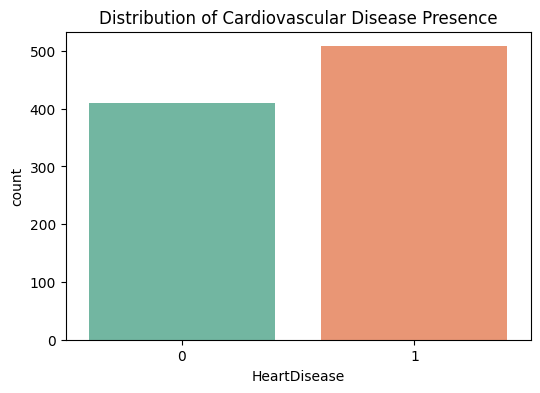

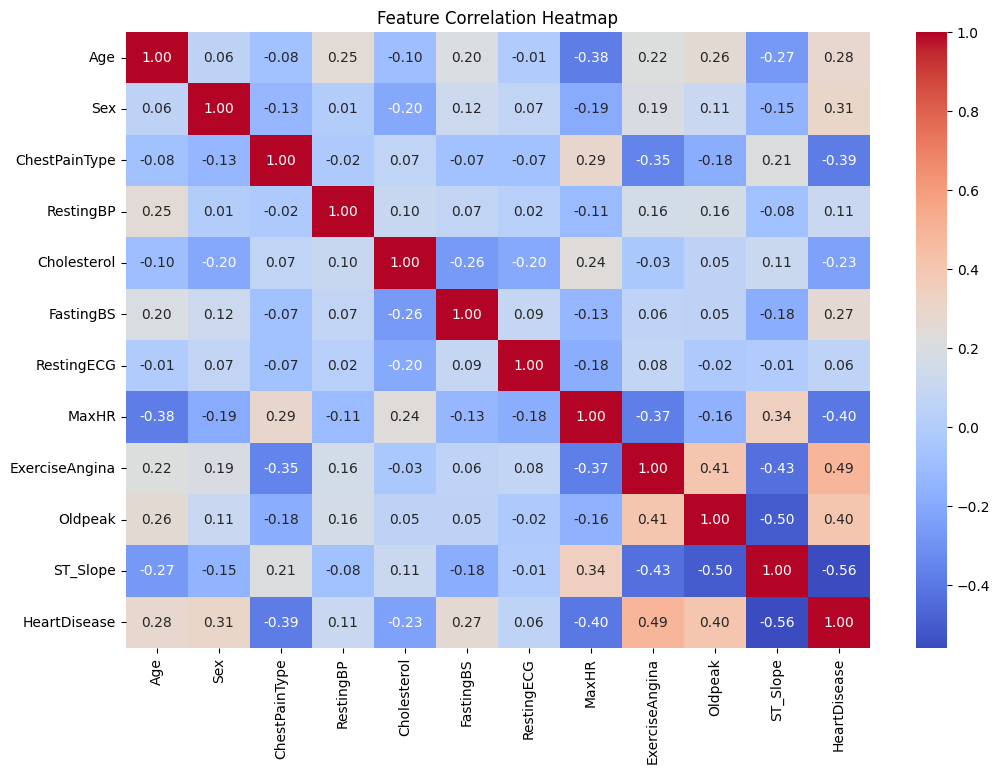


Features ready for training: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [3]:
from sklearn.preprocessing import LabelEncoder
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check for missing values
print("Missing Values:\n", df.isnull().sum())

# 2. Visualize the Target Variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Distribution of Cardiovascular Disease Presence')
plt.show()

# 3. Preprocessing: Encode Categorical Variables
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}
df_encoded = df.copy()

# Encode each categorical column and save the encoder for the web app!
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Save the dictionary of encoders
pickle.dump(label_encoders, open('label_encoders.pkl', 'wb'))

# 4. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Separate features (X) and target (y)
# Your dataset uses exactly 11 features.
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("\nFeatures ready for training:", list(X.columns))

In [4]:
# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the Streamlit app later
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Data scaled and split successfully! Training set size:", X_train.shape[0])

Data scaled and split successfully! Training set size: 734


In [5]:
# Initialize models
models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if hasattr(model, "predict_proba") else 0

    results[name] = [acc, prec, rec, f1, roc]

# Display Results
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']).T
display(results_df.sort_values(by='F1-Score', ascending=False))

# Save the best model (Assuming KNN or Random Forest based on results)
best_model = models["K-Nearest Neighbors"]
pickle.dump(best_model, open('heart_model.pkl', 'wb'))
print("\nModel saved as 'heart_model.pkl'")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
K-Nearest Neighbors,0.891304,0.894231,0.911765,0.902913,0.919237
Random Forest,0.875000,0.876190,0.901961,0.888889,0.922884
Logistic Regression,0.869565,0.848214,0.931373,0.887850,0.897059
Decision Tree,0.788043,0.811881,0.803922,0.807882,0.786107



Model saved as 'heart_model.pkl'


In [6]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load the trained model, scaler, and the newly saved label encoders
model = pickle.load(open('heart_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
encoders = pickle.load(open('label_encoders.pkl', 'rb'))

st.title("🩺 Cardiovascular Risk Prediction System")
st.write("Enter the patient's clinical and demographic features to predict cardiovascular risk.")

# Create input layout
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", min_value=1, max_value=120, value=50)
    sex = st.selectbox("Sex", ['M', 'F'])
    cp = st.selectbox("Chest Pain Type", ['ATA', 'NAP', 'ASY', 'TA'])
    trestbps = st.number_input("Resting Blood Pressure (mm Hg)", min_value=50, max_value=250, value=120)
    chol = st.number_input("Serum Cholesterol (mg/dl)", min_value=0, max_value=600, value=200)
    fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0, 1])

with col2:
    restecg = st.selectbox("Resting ECG Results", ['Normal', 'ST', 'LVH'])
    thalach = st.number_input("Maximum Heart Rate Achieved", min_value=50, max_value=250, value=150)
    exang = st.selectbox("Exercise Induced Angina", ['N', 'Y'])
    oldpeak = st.number_input("Oldpeak (ST Depression)", min_value=-3.0, max_value=10.0, value=1.0)
    slope = st.selectbox("ST Slope", ['Up', 'Flat', 'Down'])

if st.button("Predict Risk"):
    try:
        # Transform the user's text inputs into numbers using the saved encoders
        sex_enc = encoders['Sex'].transform([sex])[0]
        cp_enc = encoders['ChestPainType'].transform([cp])[0]
        restecg_enc = encoders['RestingECG'].transform([restecg])[0]
        exang_enc = encoders['ExerciseAngina'].transform([exang])[0]
        slope_enc = encoders['ST_Slope'].transform([slope])[0]

        # Combine all 11 inputs into the exact order the model expects
        user_data = np.array([[age, sex_enc, cp_enc, trestbps, chol, fbs, restecg_enc, thalach, exang_enc, oldpeak, slope_enc]])

        # Scale the data
        scaled_data = scaler.transform(user_data)

        # Make prediction
        prediction = model.predict(scaled_data)
        probability = model.predict_proba(scaled_data)[0][1] if hasattr(model, "predict_proba") else None

        st.markdown("---")
        if prediction[0] == 1:
            if probability is not None:
                st.error(f"⚠️ **High Risk Detected.** (Confidence: {probability*100:.2f}%)")
            else:
                 st.error("⚠️ **High Risk Detected.** The model predicts a high likelihood of cardiovascular disease.")
        else:
            if probability is not None:
                st.success(f"✅ **Low Risk.** (Confidence: {(1-probability)*100:.2f}%)")
            else:
                 st.success("✅ **Low Risk.** The model predicts a low likelihood of cardiovascular disease.")
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")

Writing app.py


In [7]:
%%writefile app_flask.py
from flask import Flask, request, render_template_string
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained model, scaler, and label encoders
model = pickle.load(open('heart_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
encoders = pickle.load(open('label_encoders.pkl', 'rb'))

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Cardiovascular Risk Predictor</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 40px; background-color: #f4f7f6; color: #333; }
        .container { max-width: 900px; margin: auto; background: white; padding: 30px; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
        h1 { color: #2c3e50; text-align: center; }
        .input-box { border: 2px dashed #3498db; padding: 20px; border-radius: 5px; margin-bottom: 20px; background-color: #f9fbfc; }
        .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 15px; }
        label { font-weight: bold; font-size: 14px;}
        input, select { width: 100%; padding: 10px; margin-top: 5px; border: 1px solid #ccc; border-radius: 4px; box-sizing: border-box; }
        input[type="submit"] { background-color: #3498db; color: white; border: none; padding: 12px 24px; cursor: pointer; border-radius: 4px; font-size: 16px; margin-top: 20px; font-weight: bold;}
        input[type="submit"]:hover { background-color: #2980b9; }
        .high-risk { background-color: #ffeaea; color: #c0392b; padding: 20px; border-radius: 5px; text-align: center; font-weight: bold; font-size: 18px; margin-top: 20px; border: 1px solid #c0392b;}
        .low-risk { background-color: #eafaf1; color: #27ae60; padding: 20px; border-radius: 5px; text-align: center; font-weight: bold; font-size: 18px; margin-top: 20px; border: 1px solid #27ae60;}
    </style>
</head>
<body>
    <div class="container">
        <h1>🩺 Cardiovascular Risk Prediction System</h1>

        <div class="input-box">
            <form method="POST">
                <div class="form-grid">
                    <div>
                        <label>Age</label>
                        <input type="number" name="age" required value="50">
                    </div>
                    <div>
                        <label>Sex</label>
                        <select name="sex">
                            <option value="M">Male (M)</option>
                            <option value="F">Female (F)</option>
                        </select>
                    </div>
                    <div>
                        <label>Chest Pain Type</label>
                        <select name="cp">
                            <option value="ATA">Atypical Angina (ATA)</option>
                            <option value="NAP">Non-Anginal Pain (NAP)</option>
                            <option value="ASY">Asymptomatic (ASY)</option>
                            <option value="TA">Typical Angina (TA)</option>
                        </select>
                    </div>
                    <div>
                        <label>Resting Blood Pressure (mm Hg)</label>
                        <input type="number" name="trestbps" required value="120">
                    </div>
                    <div>
                        <label>Serum Cholesterol (mg/dl)</label>
                        <input type="number" name="chol" required value="200">
                    </div>
                    <div>
                        <label>Fasting Blood Sugar > 120 mg/dl</label>
                        <select name="fbs">
                            <option value="0">False (0)</option>
                            <option value="1">True (1)</option>
                        </select>
                    </div>
                    <div>
                        <label>Resting ECG Results</label>
                        <select name="restecg">
                            <option value="Normal">Normal</option>
                            <option value="ST">ST-T wave abnormality</option>
                            <option value="LVH">Left ventricular hypertrophy</option>
                        </select>
                    </div>
                    <div>
                        <label>Maximum Heart Rate Achieved</label>
                        <input type="number" name="thalach" required value="150">
                    </div>
                    <div>
                        <label>Exercise Induced Angina</label>
                        <select name="exang">
                            <option value="N">No (N)</option>
                            <option value="Y">Yes (Y)</option>
                        </select>
                    </div>
                    <div>
                        <label>Oldpeak (ST Depression)</label>
                        <input type="number" step="0.1" name="oldpeak" required value="1.0">
                    </div>
                    <div>
                        <label>ST Slope</label>
                        <select name="slope">
                            <option value="Up">Up</option>
                            <option value="Flat">Flat</option>
                            <option value="Down">Down</option>
                        </select>
                    </div>
                </div>
                <div style="text-align: center;">
                    <input type="submit" value="Predict Risk">
                </div>
            </form>
        </div>

        {% if result_html %}
            {{ result_html | safe }}
        {% endif %}
    </div>
</body>
</html>
"""

@app.route('/', methods=['GET', 'POST'])
def index():
    result_html = ""
    if request.method == 'POST':
        try:
            # 1. Fetch form data
            age = float(request.form['age'])
            sex = request.form['sex']
            cp = request.form['cp']
            trestbps = float(request.form['trestbps'])
            chol = float(request.form['chol'])
            fbs = int(request.form['fbs'])
            restecg = request.form['restecg']
            thalach = float(request.form['thalach'])
            exang = request.form['exang']
            oldpeak = float(request.form['oldpeak'])
            slope = request.form['slope']

            # 2. Transform the user's text inputs into numbers using the saved encoders
            sex_enc = encoders['Sex'].transform([sex])[0]
            cp_enc = encoders['ChestPainType'].transform([cp])[0]
            restecg_enc = encoders['RestingECG'].transform([restecg])[0]
            exang_enc = encoders['ExerciseAngina'].transform([exang])[0]
            slope_enc = encoders['ST_Slope'].transform([slope])[0]

            # 3. Combine and Scale
            user_data = np.array([[age, sex_enc, cp_enc, trestbps, chol, fbs, restecg_enc, thalach, exang_enc, oldpeak, slope_enc]])
            scaled_data = scaler.transform(user_data)

            # 4. Predict
            prediction = model.predict(scaled_data)[0]

            # 5. Format Output
            if prediction == 1:
                result_html = '<div class="high-risk">⚠️ High Risk Detected. The model predicts a high likelihood of cardiovascular disease.</div>'
            else:
                result_html = '<div class="low-risk">✅ Low Risk. The model predicts a low likelihood of cardiovascular disease.</div>'
        except Exception as e:
            result_html = f'<div style="color: red; text-align: center;">An error occurred during prediction: {e}</div>'

    return render_template_string(HTML_TEMPLATE, result_html=result_html)

if __name__ == '__main__':
    app.run(port=5000)

Writing app_flask.py


In [8]:
import os
import time
from google.colab import output

# 1. Terminate any previous instances to avoid port conflicts
os.system("pkill -f app_flask.py")
os.system("pkill -f streamlit")

# 2. Run the Flask app in the background
os.system("nohup python app_flask.py > flask_logs.txt 2>&1 &")

# Give the server a couple of seconds to boot up
time.sleep(3)

print("✅ Flask Server is running!")
print("Click the secure link below to open your Web App:")

# 3. Create a direct link to the app using Colab's proxy
output.serve_kernel_port_as_window(5000)

✅ Flask Server is running!
Click the secure link below to open your Web App:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [9]:
import os
import time
from google.colab import output

# 1. Terminate any previous instances to avoid port conflicts
os.system("pkill -f app_flask.py")
os.system("pkill -f streamlit")

# 2. Run the Flask app in the background
os.system("nohup python app_flask.py > flask_logs.txt 2>&1 &")

# Give the server a couple of seconds to boot up
time.sleep(3)

print("✅ Flask Server is running!")
print("Your Web App will load directly below:")

# 3. Create an embedded iframe for the app using Colab's proxy
output.serve_kernel_port_as_iframe(5000)

✅ Flask Server is running!
Your Web App will load directly below:


<IPython.core.display.Javascript object>